# Desafio: Implementando uma Fila com Duas Pilhas

https://www.hackerrank.com/challenges/queue-using-two-stacks/problem?isFullScreen=true

Uma **Fila** (Queue) é um tipo abstrato de dados que mantém a ordem em que os elementos foram adicionados. Ela segue o princípio **FIFO** (*First-In-First-Out*), onde o primeiro elemento adicionado é o primeiro a ser removido.

### Operações Básicas:
*   **Enqueue**: Adiciona um novo elemento ao final da fila.
*   **Dequeue**: Remove o elemento da frente da fila e o retorna.

---

## 📝 Descrição do Problema

Neste desafio, você deve implementar uma fila utilizando **duas pilhas**. Em seguida, processe $n$ consultas, onde cada consulta é de um dos 3 tipos a seguir:

1.  **`1 x`**: *Enqueue* — Adiciona o elemento $x$ ao final da fila.
2.  **`2`**: *Dequeue* — Remove o elemento à frente da fila.
3.  **`3`**: *Print* — Imprime o elemento à frente da fila.

### Formato de Entrada
*   A primeira linha contém um único inteiro, $q$, denotando o número de consultas.
*   As $q$ linhas subsequentes contêm uma consulta no formato descrito acima.

### Restrições
*   $1 \leq q \leq 10^5$
*   $1 \leq type \leq 3$
*   $1 \leq x \leq 10^9$
*   É garantido que sempre haverá um elemento válido para as consultas do tipo **2** e **3**.

### Formato de Saída
Para cada consulta do tipo **3**, imprima o valor do elemento à frente da fila em uma nova linha.

---

## 📥 Exemplo de Entrada
```text
10
1 42
2
1 14
3
1 28
3
1 60
1 78
2
2
```

## 📤 Exemplo de Saída
```text
14
14
```

---

## 💡 Explicação Passo a Passo

Considerando a sequência de operações do exemplo:

1.  **Enqueue 42**: Fila = `[42]`
2.  **Dequeue**: Fila = `[]`
3.  **Enqueue 14**: Fila = `[14]`
4.  **Print**: Imprime `14`
5.  **Enqueue 28**: Fila = `[14, 28]`
6.  **Print**: Imprime `14`
7.  **Enqueue 60**: Fila = `[14, 28, 60]`
8.  **Enqueue 78**: Fila = `[14, 28, 60, 78]`
9.  **Dequeue**: Fila = `[28, 60, 78]`
10. **Dequeue**: Fila = `[60, 78]`

---

## 🛠 Dica de Implementação: A Lógica das Duas Pilhas
Para simular uma fila (FIFO) usando pilhas (LIFO), você pode usar:
*   **Pilha de Entrada (`stack_in`)**: Onde você sempre faz o *push* dos novos elementos (Tipo 1).
*   **Pilha de Saída (`stack_out`)**: Onde você faz o *pop* para remover (Tipo 2) ou espiar (Tipo 3).

**O segredo:** Quando a `stack_out` estiver vazia, você transfere todos os elementos da `stack_in` para ela. Isso inverte a ordem dos elementos, transformando o "último a entrar" no "primeiro a sair".

![Captura de tela 2026-05-01 130143.png](<attachment:Captura de tela 2026-05-01 130143.png>)
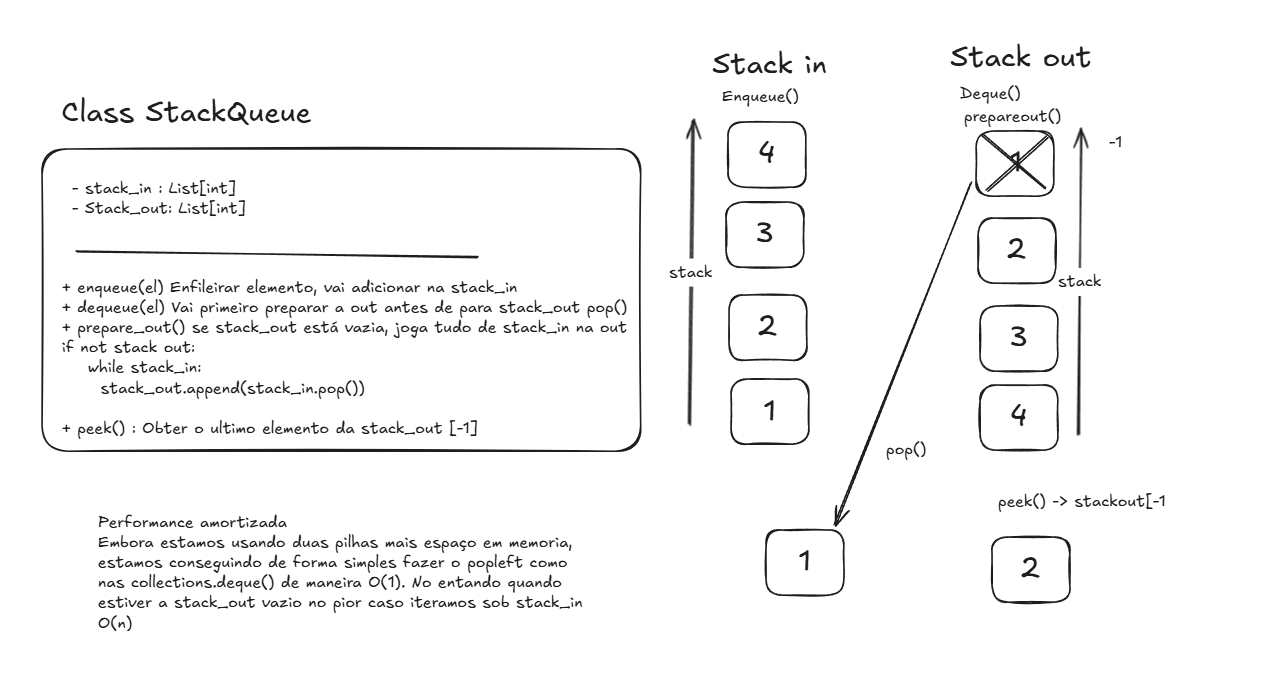

In [ ]:
import sys

class QueueTwoStacks:
    def __init__(self):
        self.stack_in = []
        self.stack_out = []

    def enqueue(self, x):
        self.stack_in.append(x)

    def _prepare_out(self):
        if not self.stack_out:
            while self.stack_in:
                self.stack_out.append(self.stack_in.pop())

    def dequeue(self):
        self._prepare_out()
        if self.stack_out:
            self.stack_out.pop()

    def peek(self):
        self._prepare_out()
        if self.stack_out:
            return self.stack_out[-1]

def process_queries():
    q_two_stacks = QueueTwoStacks()
    input_data = sys.stdin.read().splitlines()
    ENQUEUE = '1'
    DEQUEUE = '2'
    PEEK = '3'

    for i in range(1, len(input_data)):
        query = input_data[i].split()
        type = query[0]
        
        if type == ENQUEUE:
            q_two_stacks.enqueue(query[1])
        elif type == DEQUEUE:
            q_two_stacks.dequeue()
        elif type == PEEK:
            print(q_two_stacks.peek())

if __name__ == "__main__":
    process_queries()
